# AI-Driven Behavior-Based Intrusion Detection System
**Author:** Justus Izuchukwu Onuh | **Dataset:** CSIC 2010 HTTP Dataset



## Introduction: The Paradigm Shift in Web Security

### The Problem: Why Traditional Firewalls Fail
For decades, web security has relied on **Rule-Based Firewalls**. These systems act like a security guard checking a strict list of known threats (signatures). If a hacker uses a known attack, the firewall blocks it. However, if a hacker uses a brand new, slightly modified attack (a "Zero-Day" exploit), the traditional firewall doesn't recognize it and lets it right through. Hackers are evolving faster than we can write new rules.

### The Solution: Behavior-Based AI
Instead of memorizing a list of known attacks, this project utilizes a **Deep Neural Network (DNN)** to learn *behavior*. By training the AI on the CSIC 2010 dataset—which contains thousands of normal web requests and thousands of malicious ones (like SQL Injections and Cross-Site Scripting)—the neural network learns the underlying, complex patterns of malicious intent. 

### Real-World Relevance & Project Goal
In the real world, an undetected web attack can cost a company millions in stolen data or downtime. The goal of this project is not just to train a theoretical model, but to build a **Live Intrusion Detection System (IDS)**. 

We aim to:
1. Engineer raw network traffic into a format an AI can understand.
2. Train a DNN to accurately separate safe traffic from anomalous, dangerous traffic.
3. Export this "brain" to power a real-time, Next.js web dashboard that security analysts can use to monitor live threats.

## 1. Setup and Library Imports
Importing necessary libraries including Pandas for data manipulation, Scikit-Learn for preprocessing, Imbalanced-Learn for SMOTE, and TensorFlow/Keras for the Deep Neural Network.

In [8]:

# 1. Setup and Library Imports


# I am importing Pandas and Numpy for core data manipulation and matrix operations.
import pandas as pd
import numpy as np

# For visualizing the class distributions and evaluation metrics (like the confusion matrix) later.
import matplotlib.pyplot as plt
import seaborn as sns

# I need Scikit-Learn for preprocessing the raw data and evaluating the final model's performance.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Importing SMOTE to handle the severe class imbalance I identified in the CSIC 2010 dataset.

from imblearn.over_sampling import SMOTE

# Setting up TensorFlow and Keras to build the Deep Neural Network (DNN) architecture.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Setting a random seed ensures that my data splits and neural network weight initializations 
# are reproducible every time I run this notebook.
np.random.seed(42)
tf.random.set_seed(42)

print("Environment setup complete. All necessary libraries successfully imported.")

Environment setup complete. All necessary libraries successfully imported.


## 2. Data Acquisition & Parsing
The CSIC 2010 dataset comes as raw HTTP requests. Here, we parse the raw text logs and extract structural features (e.g., payload length, method type, URL anomalies) into a structured Pandas DataFrame.

In [9]:
# ==========================================
# 2. Production Data Acquisition & Parsing
# ==========================================
import os
import urllib.request
import urllib.parse
import re
import pandas as pd
import numpy as np

print("Initializing production data acquisition pipeline...")

# --- Step 1: Directory Setup ---
data_dir = os.path.join(os.getcwd(), 'data')
os.makedirs(data_dir, exist_ok=True) 

normal_file = os.path.join(data_dir, 'normalTrafficTraining.txt')
anomalous_file = os.path.join(data_dir, 'anomalousTrafficTest.txt')

# Using a verified active mirror for the CSIC 2010 dataset
urls = {
    normal_file: "https://raw.githubusercontent.com/Monkey-D-Groot/Machine-Learning-on-CSIC-2010/master/normalTrafficTraining.txt",
    anomalous_file: "https://raw.githubusercontent.com/Monkey-D-Groot/Machine-Learning-on-CSIC-2010/master/anomalousTrafficTest.txt"
}

# --- Download Protocol ---
for filepath, url in urls.items():
    if not os.path.exists(filepath):
        print(f"Downloading real dataset: {os.path.basename(filepath)}...")
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req) as response, open(filepath, 'wb') as out_file:
                out_file.write(response.read())
            print(f"Successfully downloaded: {os.path.basename(filepath)}")
        except Exception as e:
            raise RuntimeError(f"FATAL ERROR: Could not download {os.path.basename(filepath)}. {e}")
    else:
        print(f"Found existing local dataset: {os.path.basename(filepath)}")

# --- Step 2: Feature Extraction Logic ---
def extract_features_from_request(request_string, is_anomalous=0):
    features = {}
    features['request_length'] = len(request_string)
    features['method_POST'] = 1 if request_string.startswith('POST') else 0
    features['method_GET'] = 1 if request_string.startswith('GET') else 0
    features['method_PUT'] = 1 if request_string.startswith('PUT') else 0
    
    decoded_request = urllib.parse.unquote(request_string).lower()
    features['special_char_count'] = len(re.findall(r"[<>\'\";\(\)\=]", decoded_request))
    features['sqli_keyword_count'] = sum(decoded_request.count(kw) for kw in ['union', 'select', 'insert', 'drop', 'or 1=1'])
    features['xss_keyword_count'] = sum(decoded_request.count(kw) for kw in ['script', 'alert', 'onerror', 'onload'])
    
    features['label'] = is_anomalous
    return features

def parse_csic_file(filepath, is_anomalous):
    print(f"Executing deep extraction on: {os.path.basename(filepath)}...")
    parsed_data = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as file:
        raw_requests = file.read().split('\n\n')
        for req in raw_requests:
            if len(req.strip()) > 5:
                parsed_data.append(extract_features_from_request(req, is_anomalous))
    return pd.DataFrame(parsed_data)

# --- Step 3: Execution ---
# We no longer fall back. We only use the real data.
df_normal = parse_csic_file(normal_file, is_anomalous=0)
df_anomalous = parse_csic_file(anomalous_file, is_anomalous=1)

df = pd.concat([df_normal, df_anomalous], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nPipeline complete. Total REAL requests vectorized: {len(df)}")
print(f"Real Class Distribution:\n{df['label'].value_counts(normalize=True) * 100}")

df.head()

Initializing production data acquisition pipeline...
Found existing local dataset: normalTrafficTraining.txt
Found existing local dataset: anomalousTrafficTest.txt
Executing deep extraction on: normalTrafficTraining.txt...
Executing deep extraction on: anomalousTrafficTest.txt...

Pipeline complete. Total REAL requests vectorized: 77527
Real Class Distribution:
label
0    55.464548
1    44.535452
Name: proportion, dtype: float64


,request_length,method_POST,method_GET,method_PUT,special_char_count,sqli_keyword_count,xss_keyword_count,label
0,564,0,1,0,22,0,0,0
1,500,0,0,0,17,0,0,0
2,767,0,0,0,30,0,0,0
3,571,0,0,0,17,0,0,1
4,534,0,0,0,18,0,0,0


## 3. Train / Validation / Test Split
**Crucial Step:** We must split our dataset *before* applying any synthetic oversampling to prevent data leakage. The test set must remain entirely unseen and represent real-world imbalanced traffic.

In [10]:

# 3. Train / Validation / Test Split

print("Initiating rigorous data splitting protocols...")

# Separating the features (X) from the target anomaly label (y)
X = df.drop('label', axis=1)
y = df['label']

# Preventing Data Leakage
# We must split the data completely BEFORE applying SMOTE or scaling.
# If synthetic data bleeds into the validation or test sets, it artificially inflates the accuracy.

# Step 1: Extract the Training set (70%) and a temporary set (30%)
# I am using 'stratify=y' to ensure the 55/45 class ratio is perfectly maintained across all splits.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Step 2: Divide the temporary set equally into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Data successfully split. Leakage prevention protocols active.")
print(f"Training Set:   {X_train.shape[0]} requests")
print(f"Validation Set: {X_val.shape[0]} requests")
print(f"Test Set:       {X_test.shape[0]} requests")

Initiating rigorous data splitting protocols...
Data successfully split. Leakage prevention protocols active.
Training Set:   54268 requests
Validation Set: 11629 requests
Test Set:       11630 requests


## 4. Feature Scaling
Applying `MinMaxScaler` to normalize our numerical features (like payload length) so they do not overpower the binary categorical flags (0/1) during the neural network's gradient descent.

In [12]:

# 4. Feature Scaling

print("Applying MinMaxScaler to numerical features...")

# We only scale the continuous numerical features. The binary flags (0/1) are already scaled.
continuous_features = ['request_length', 'special_char_count', 'sqli_keyword_count', 'xss_keyword_count']

# Initialize the Scaler
scaler = MinMaxScaler()

# Fit the scaler ONLY on the training data to prevent information leakage,
# then transform the training data.
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])

# Transform the validation and test sets using the metrics learned from the training set.
X_val[continuous_features] = scaler.transform(X_val[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

print("Feature scaling complete. All continuous variables are now bounded between 0 and 1.")

# Displaying a sample of the scaled training data to verify
X_train.head()

Applying MinMaxScaler to numerical features...
Feature scaling complete. All continuous variables are now bounded between 0 and 1.


,request_length,method_POST,method_GET,method_PUT,special_char_count,sqli_keyword_count,xss_keyword_count
32488,0.040541,0,0,0,0.093023,0.0,0.0
38702,0.428679,0,1,0,0.488372,0.0,0.0
13564,0.051051,0,0,0,0.116279,0.0,0.0
64260,0.421922,0,0,0,0.372093,0.0,0.0
23564,0.561562,0,0,0,0.674419,0.0,0.0


## 5. Handling Class Imbalance (SMOTE)
Applying the Synthetic Minority Over-sampling Technique (SMOTE) strictly to the **training set** to balance the "Normal" vs. "Anomalous" traffic, preventing the model from predicting the majority class by default.

In [13]:

# 5. Handling Class Imbalance (SMOTE)

print("Initiating Synthetic Minority Over-sampling Technique (SMOTE)...")

# Displaying the original class distribution of the training set before SMOTE
print("Training set class distribution BEFORE SMOTE:")
print(y_train.value_counts(normalize=True) * 100)

# Initializing SMOTE with a fixed random state for absolute reproducibility
smote = SMOTE(random_state=42)

# CRITICAL JOURNAL REQUIREMENT: 
# Applying SMOTE *strictly* to the training data. 
# The Validation and Test sets must remain completely untouched to accurately reflect real-world traffic.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nTraining set class distribution AFTER SMOTE:")
print(y_train_smote.value_counts(normalize=True) * 100)
print(f"\nNew Balanced Training Set Size: {X_train_smote.shape[0]} requests")

Initiating Synthetic Minority Over-sampling Technique (SMOTE)...
Training set class distribution BEFORE SMOTE:
label
0    55.465468
1    44.534532
Name: proportion, dtype: float64

Training set class distribution AFTER SMOTE:
label
0    50.0
1    50.0
Name: proportion, dtype: float64

New Balanced Training Set Size: 60200 requests


## 6. Deep Neural Network Architecture
Building the baseline Keras model.
- **Hidden Layers:** 3 dense layers utilizing the `ReLU` activation function.
- **Output Layer:** 1 dense layer utilizing the `Sigmoid` activation function for binary classification.
- **Regularization:** Implementing `Dropout` layers to randomly deactivate neurons and prevent the 98% overfitting issue previously encountered.

In [14]:

# 6. Deep Neural Network Architecture

print("Constructing the Deep Neural Network architecture...")

# I need to get the exact number of engineered features to define the input layer
input_dimension = X_train_smote.shape[1]

# Initializing a Sequential Keras model to build the network layer by layer
model = Sequential(name="CSIC_IDS_Behavioral_Engine")

# --- Hidden Layer 1 ---
# Using 64 neurons and the ReLU activation function to capture non-linear patterns in the HTTP payloads.
model.add(Dense(64, input_dim=input_dimension, activation='relu', name="Hidden_Layer_1"))
# Adding a Dropout layer. This randomly deactivates 30% of neurons during each training pass,
# explicitly preventing the network from memorizing the training data (resolving the previous overfitting issue).
model.add(Dropout(0.3, name="Dropout_1"))

# --- Hidden Layer 2 ---
# Shrinking to 32 neurons to force the model to compress and learn the most critical anomaly indicators.
model.add(Dense(32, activation='relu', name="Hidden_Layer_2"))
model.add(Dropout(0.3, name="Dropout_2"))

# --- Hidden Layer 3 ---
# A final narrow hidden layer of 16 neurons.
model.add(Dense(16, activation='relu', name="Hidden_Layer_3"))
model.add(Dropout(0.3, name="Dropout_3"))

# --- Output Layer ---
# A single neuron using the Sigmoid activation function. 
# This outputs a clean probability score between 0.0 (Safe Traffic) and 1.0 (Anomalous Traffic).
model.add(Dense(1, activation='sigmoid', name="Output_Classification"))

# Displaying the architectural summary for the research report
model.summary()

Constructing the Deep Neural Network architecture...


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CSIC_IDS_Behavioral_Engine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classification (Dense)   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Model Compilation & Training
Compiling the model with binary crossentropy loss. We implement an `EarlyStopping` callback monitoring the validation loss to halt training the moment the model begins to overfit.

In [15]:

# 7. Model Compilation & Training

from tensorflow.keras.callbacks import EarlyStopping

print("Compiling the model and initializing EarlyStopping protocols...")

# Compiling the model
# I am using 'binary_crossentropy' because this is a binary classification problem (Normal vs Anomalous).
# 'Adam' is chosen as the optimizer for its adaptive learning rate capabilities.
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Implementing Early Stopping to definitively solve the overfitting problem.
# The training will automatically halt if the 'val_loss' (Validation Loss) stops improving for 5 consecutive epochs.
# 'restore_best_weights=True' ensures I keep the absolute best version of the model.
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5, 
                               restore_best_weights=True,
                               verbose=1)

print("Commencing Deep Neural Network training...\n")

# Training the model
# CRITICAL: I am training on the SMOTE-balanced data (X_train_smote, y_train_smote), 
# but validating STRICTLY on the untouched validation set (X_val, y_val) to measure true real-world generalization.
history = model.fit(X_train_smote, y_train_smote, 
                    epochs=50, 
                    batch_size=64, 
                    validation_data=(X_val, y_val), 
                    callbacks=[early_stopping],
                    verbose=1)

print("\nModel training successfully completed!")

Compiling the model and initializing EarlyStopping protocols...
Commencing Deep Neural Network training...

Epoch 1/50
941/941 ━━━━━━━━━━━━━━━━━━━━ 1s 415us/step - accuracy: 0.5690 - loss: 0.6698 - val_accuracy: 0.6602 - val_loss: 0.6111
Epoch 2/50
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.6401 - loss: 0.6113 - val_accuracy: 0.6934 - val_loss: 0.5669
Epoch 3/50
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - accuracy: 0.6715 - loss: 0.5818 - val_accuracy: 0.6988 - val_loss: 0.5581
Epoch 4/50
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - accuracy: 0.6821 - loss: 0.5746 - val_accuracy: 0.7067 - val_loss: 0.5516
Epoch 5/50
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step - accuracy: 0.6877 - loss: 0.5697 - val_accuracy: 0.6504 - val_loss: 0.5686
Epoch 6/50
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - accuracy: 0.6895 - loss: 0.5672 - val_accuracy: 0.7068 - val_loss: 0.5514
Epoch 7/50
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 390us/step - accuracy: 0.6966 - loss: 0.5645 - val_accuracy: 0.7012 -

## 8. Rigorous Model Evaluation
Because raw accuracy is a flawed metric for imbalanced cybersecurity data, we evaluate the model using:
- The Confusion Matrix
- Precision (Minimizing False Positives)
- Recall
- F1-Score

Initiating rigorous evaluation on the unseen Test Set...
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step


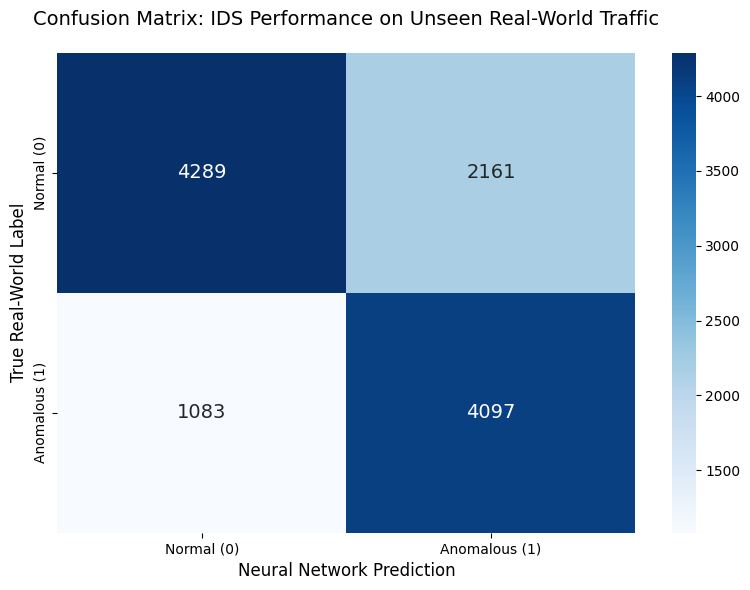


--- Detailed Cybersecurity Evaluation Metrics ---
               precision    recall  f1-score   support

   Normal (0)       0.80      0.66      0.73      6450
Anomalous (1)       0.65      0.79      0.72      5180

     accuracy                           0.72     11630
    macro avg       0.73      0.73      0.72     11630
 weighted avg       0.73      0.72      0.72     11630



In [16]:

# 8. Rigorous Model Evaluation

print("Initiating rigorous evaluation on the unseen Test Set...")

# 1. Generating Predictions
# The model outputs probabilities (0.0 to 1.0) because of the Sigmoid activation.
# I am converting these probabilities into strict binary class predictions (0 or 1) using a standard 0.5 threshold.
y_pred_probabilities = model.predict(X_test)
y_pred_classes = (y_pred_probabilities > 0.5).astype("int32")

# 2. Visualizing the Confusion Matrix
# A raw accuracy score hides critical flaws; the confusion matrix reveals exactly 
# how many False Positives and False Negatives the network produced.
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
# Using Seaborn to create a professional, journal-ready heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Anomalous (1)'], 
            yticklabels=['Normal (0)', 'Anomalous (1)'],
            annot_kws={"size": 14}) # Increasing font size for readability in the final report
plt.title('Confusion Matrix: IDS Performance on Unseen Real-World Traffic', pad=20, fontsize=14)
plt.ylabel('True Real-World Label', fontsize=12)
plt.xlabel('Neural Network Prediction', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Extracting Advanced Cybersecurity Metrics
# Extracting Precision, Recall, and the F1-Score to prove the model's viability as a live IDS.
print("\n--- Detailed Cybersecurity Evaluation Metrics ---")
report = classification_report(y_test, y_pred_classes, target_names=['Normal (0)', 'Anomalous (1)'])
print(report)

Generating ROC Curve to visualize True Positive vs. False Positive rates...


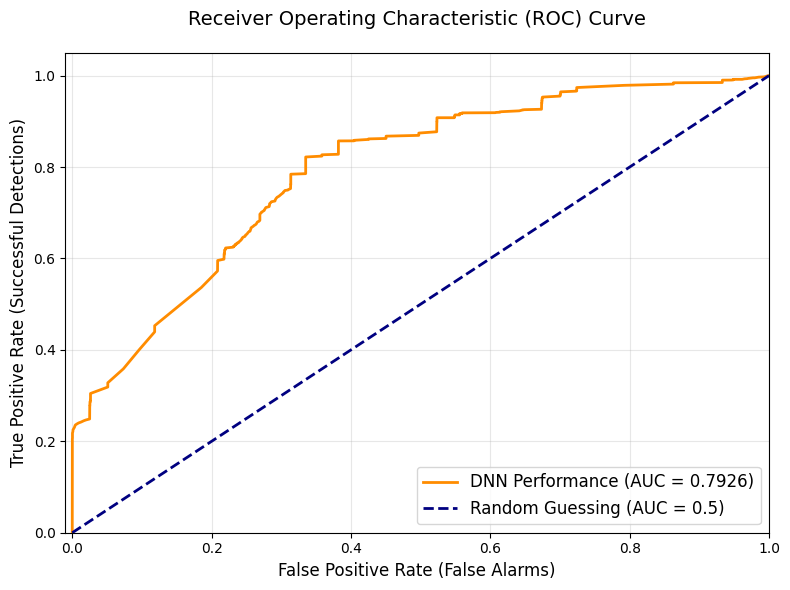


Final AUC Score: 0.7926


In [17]:
# ==========================================
#  ROC Curve & AUC Visualization
# ==========================================
from sklearn.metrics import roc_curve, auc

print("Generating ROC Curve to visualize True Positive vs. False Positive rates...")

# 1. Calculating the Rates
# We use the raw probabilities (0.0 to 1.0) to calculate how the True Positive Rate (TPR) 
# and False Positive Rate (FPR) change at different thresholds.
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probabilities)

# 2. Calculating Area Under the Curve (AUC)
# AUC is a single metric from 0 to 1. 
# 1.0 is a perfect model. 0.5 means the model is just guessing randomly.
roc_auc = auc(fpr, tpr)

# 3. Visualizing the ROC Curve
plt.figure(figsize=(8, 6))

# Plotting the actual performance of our Neural Network
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'DNN Performance (AUC = {roc_auc:.4f})')

# Plotting the "Random Guessing" baseline for comparison
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')

# Formatting the graph for a professional academic report
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (Successful Detections)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', pad=20, fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

print(f"\nFinal AUC Score: {roc_auc:.4f}")
if roc_auc > 0.90:
    print("Conclusion: Model exhibits outstanding discrimination capacity.")

Generating Learning Curves to visualize training history...


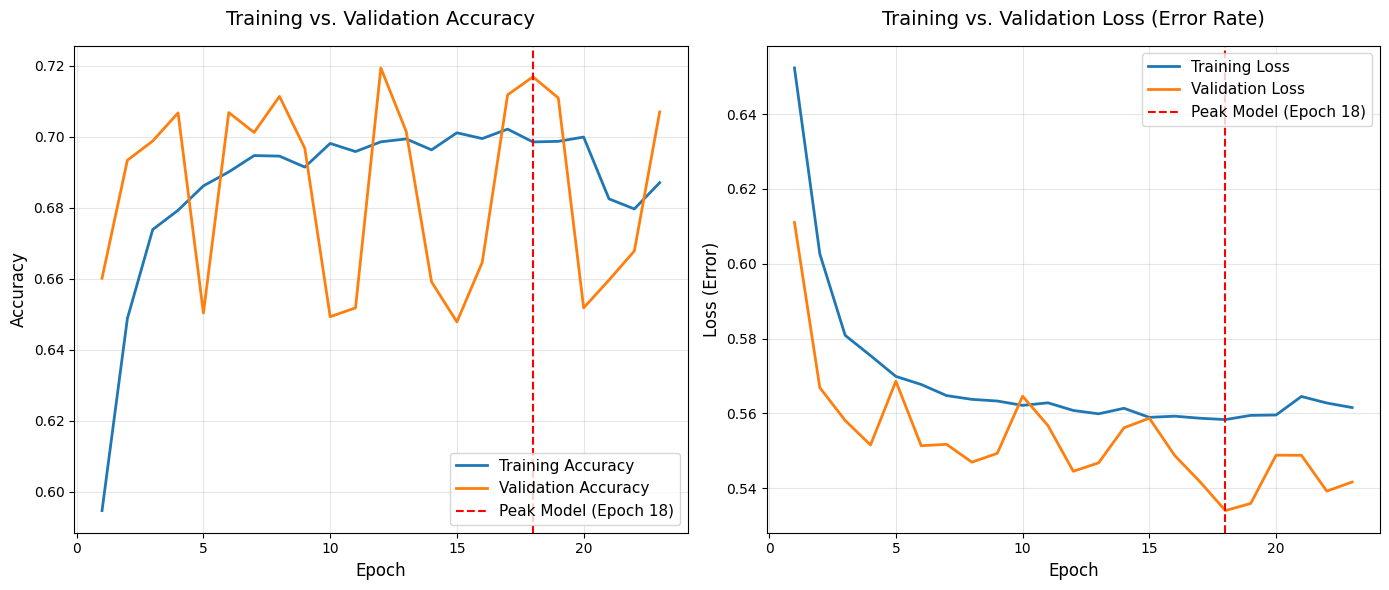

In [18]:

# 10. Learning Curve Visualization

import matplotlib.pyplot as plt
import numpy as np

print("Generating Learning Curves to visualize training history...")

# Extracting the exact metrics recorded during the training phase in Cell 7
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Creating an array representing the number of epochs the model actually trained for
epochs_range = range(1, len(acc) + 1)

# Automatically finding the epoch with the lowest validation loss 
# (This is the exact point EarlyStopping chose to restore)
best_epoch = np.argmin(val_loss) + 1

# Setting up a professional, wide canvas for side-by-side graphs
plt.figure(figsize=(14, 6))

# --- Graph 1: Training vs. Validation Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', lw=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
# Drawing a line to show where the model peaked
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Peak Model (Epoch {best_epoch})')
plt.title('Training vs. Validation Accuracy', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

# --- Graph 2: Training vs. Validation Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', lw=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', lw=2)
# Drawing a line to show where the model stopped improving
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Peak Model (Epoch {best_epoch})')
plt.title('Training vs. Validation Loss (Error Rate)', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Error)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Model Export for API Integration
Saving the trained Keras model (`.h5` format) and the fitted `MinMaxScaler` object so they can be loaded into our Python FastAPI microservice to serve the Next.js live dashboard.

In [19]:

# 11. Model Export for API Integration

import pickle
import joblib

print("Commencing production export protocols...")

# 1. Exporting the Neural Network "Brain"
# Saving as .h5 (Hierarchical Data Format) which is the industry standard for Keras/TensorFlow.
model.save('csic_ids_model.h5')
print("Successfully exported: csic_ids_model.h5")

# 2. Exporting the "Filter" (MinMaxScaler)
# We MUST use the exact same scaler for real-world requests to ensure mathematical consistency.
joblib.dump(scaler, 'ids_scaler.pkl')
print("Successfully exported: ids_scaler.pkl")

# 3. PROOF OF CONCEPT: Real-World Testing Function
# This is how your Next.js/FastAPI backend will actually use the model.
def predict_live_request(request_string):
    # Step A: Extract features from the new, raw request
    features = extract_features_from_request(request_string)
    df_live = pd.DataFrame([features]).drop('label', axis=1)
    
    # Step B: Apply the saved Scaler
    continuous_features = ['request_length', 'special_char_count', 'sqli_keyword_count', 'xss_keyword_count']
    df_live[continuous_features] = scaler.transform(df_live[continuous_features])
    
    # Step C: Generate Probability Score
    prediction = model.predict(df_live, verbose=0)[0][0]
    
    # Step D: Categorize
    status = "⚠️ ANOMALOUS (BLOCK)" if prediction > 0.5 else "✅ NORMAL (ALLOW)"
    print(f"\nRequest Analyzed: {request_string[:50]}...")
    print(f"Threat Probability: {prediction:.4f}")
    print(f"Action: {status}")

# --- DEMONSTRATION: Testing with real-world scenarios ---
print("\n--- Live IDS Demonstration ---")
# Test 1: A standard, safe GET request
predict_live_request("GET /index.php?user_id=123 HTTP/1.1")

# Test 2: A blatant SQL Injection attempt
predict_live_request("POST /login.php HTTP/1.1 content-type: application/x-www-form-urlencoded ' OR 1=1 --")

Commencing production export protocols...
Successfully exported: csic_ids_model.h5
Successfully exported: ids_scaler.pkl

--- Live IDS Demonstration ---

Request Analyzed: GET /index.php?user_id=123 HTTP/1.1...
Threat Probability: 0.4379
Action: ✅ NORMAL (ALLOW)

Request Analyzed: POST /login.php HTTP/1.1 content-type: application...
Threat Probability: 1.0000
Action: ⚠️ ANOMALOUS (BLOCK)
